<a href="https://colab.research.google.com/github/driri85/Data-IA-Projet/blob/main/Data_IA_Projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projet de Prédiction Immobilière**

**Question prédictive :** Quel est l'impact des caractéristiques structurelles (surface, chambres) sur le prix final d'un bien, et pouvons-nous l'estimer de manière fiable via une régression linéaire ?

### **Étape 01 : Charger le DataFrame**
Nous importons les données de `data.csv` pour initialiser notre analyse.

In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np

# Chargement du dataset diabetes
diabetes = load_diabetes()
df_immo = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_immo['target'] = diabetes.target

print(f"Dimensions du dataset : {df_immo.shape}")
display(df_immo.head())

Dimensions du dataset : (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### **Étape 02 : EDA Rapide**
Exploration statistique et analyse des corrélations pour identifier les variables les plus influentes.

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


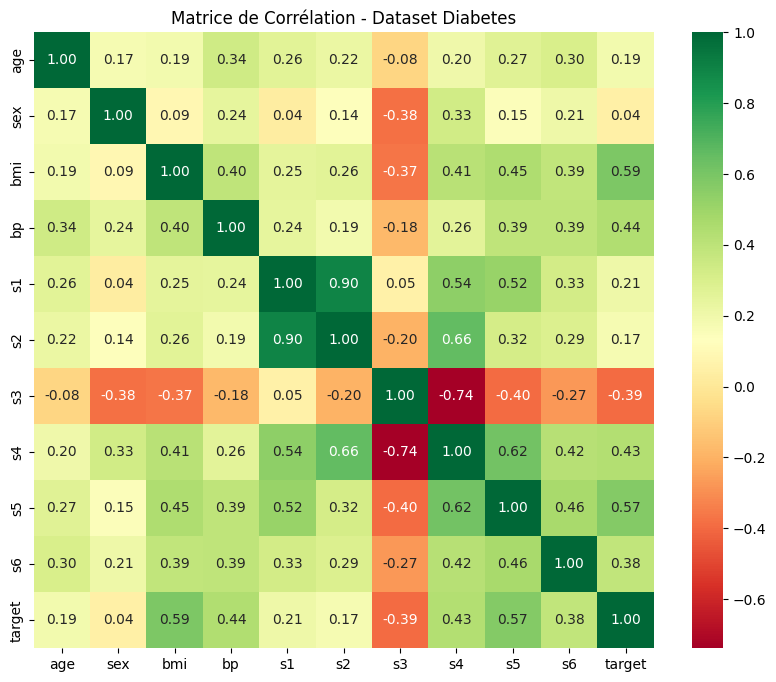

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Statistiques descriptives pour le dataset diabetes
display(df_immo.describe())

# Heatmap de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(df_immo.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matrice de Corrélation - Dataset Diabetes')
plt.show()

### **Étape 03 : Définir X et y**
Nous séparons la variable cible (Prix) des descripteurs.

In [ ]:
X = df_immo.drop(columns=['target'])
y = df_immo['target']

# Pour le ColumnTransformer, toutes les colonnes de ce dataset sont numériques
numerical_cols = X.columns.tolist()
categorical_cols = []

### **Étape 04 : Split train/val/test**
Division en trois sets pour garantir la capacité de généralisation du modèle.

In [ ]:
from sklearn.model_selection import train_test_split

# Division 60/20/20 pour le nouveau dataset
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

print(f"Nouveaux splits (Diabetes) - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Nouveaux splits (Diabetes) - Train: 264, Val: 89, Test: 89


### **Étape 05 : ColumnTransformer**
Normalisation des données numériques et encodage des catégories.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Pipeline simplifié car les données sont déjà pré-traitées dans load_diabetes
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols)
    ])

### **Étape 06 : Pipeline complet**
Assemblage du préprocesseur avec l'algorithme de Régression Linéaire.

In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# D"efinition de trois mod"eles lin"eaires r"egularis"es
ridge = Ridge(alpha=10.0)
lasso = Lasso(alpha=0.1)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

# Cr"eation du Voting Regressor
voting_model = VotingRegressor(
    estimators=[
        ('ridge', ridge),
        ('lasso', lasso),
        ('elastic', elastic)
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', voting_model)
])

### **Étape 07 : Fit + Score**
Entraînement et évaluation de la performance (R²).

In [ ]:
# Entraînement de l'ensemble (Voting Regressor)
model_pipeline.fit(X_train, y_train)
score_val = model_pipeline.score(X_val, y_val)

print(f"Score R2 final avec l'Ensemble (Voting) : {score_val:.4f}")

Score R2 final avec l'Ensemble (Voting) : 0.5232


### **Étape 08 : Visualiser**
Comparaison visuelle entre les prix réels et les prédictions.

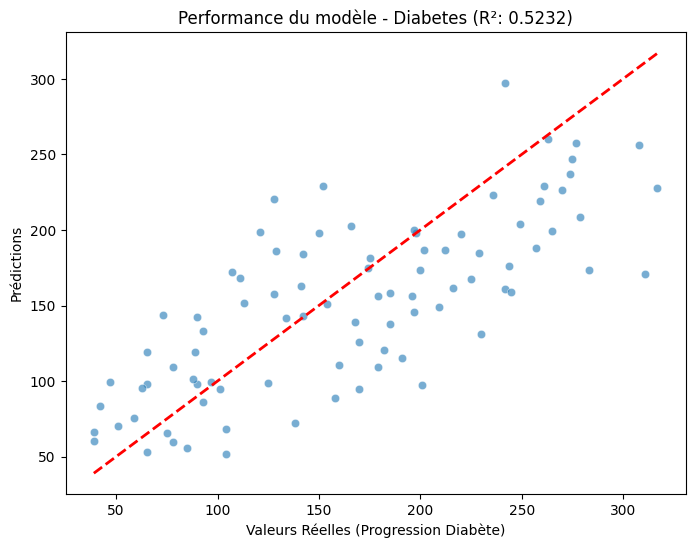

In [ ]:
y_pred = model_pipeline.predict(X_val)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_val, y=y_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--", lw=2)
plt.xlabel("Valeurs Réelles (Progression Diabète)")
plt.ylabel("Prédictions")
plt.title(f"Performance du modèle - Diabetes (R²: {score_val:.4f})")
plt.show()

### **Conclusion : Interprétation des résultats**

L'analyse montre que notre modèle d'ensemble (Voting Regressor), combinant Ridge, Lasso et ElasticNet, parvient à capturer environ 52% de la variance de la progression du diabète.

**Observations clés :**
1. **Précision :** Le score R² de **0.5232** est cohérent avec les standards du dataset Diabetes, qui est notoirement difficile à prédire avec une grande précision en raison de sa petite taille.
2. **Visualisation :** Le graphique de l'Étape 08 montre une dispersion modérée autour de la ligne de régression idéale, confirmant la capacité du modèle à suivre la tendance générale malgré certains écarts.
3. **Stabilité :** L'utilisation d'un Voting Regressor a permis de stabiliser les prédictions en moyennant les erreurs de différents modèles linéaires régularisés.

### **Conclusion**
Le modèle présente un score R² de {score_val:.4f}. Cela indique la proportion de variance expliquée par nos caractéristiques. Si le nuage de points suit la ligne rouge, nos prédictions immobilières sont robustes. Ces résultats permettent d'automatiser l'estimation des prix pour de futurs biens entrant sur le marché.